# GVH Diagonal Cubic — RACC-C.3
## Two-Observer Observation Robustness Benchmark

**Auteur :** Charlemagne O Laurince  
**Statut :** benchmark/interface observationnelle — aucune modification du noyau gravitationnel GVH Diagonal

Objectif : tester la robustesse de
\[
D_T^{\rm phys}\neq D_{T,O}^{\rm obs}
\]
quand on ajoute bruit, cadence finie, champ de vue et propagation.

**Règle scientifique :** aucun écart A/B n'est interprété comme nouvelle physique GVH tant que les effets standards d'observation ne sont pas contrôlés.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from dataclasses import dataclass
RNG=np.random.default_rng(20260810)
print("RACC-C.3 environment ready")

RACC-C.3 environment ready


## 1. Champ physique
\[
F(x)=A\exp\left(-\frac{x^2}{2\sigma^2}\right),\qquad x(t)=vt.
\]
Pour ce benchmark scalaire minimal,
\[
D_T^{\rm phys}=|F(t_1)-F(t_0)|.
\]

In [2]:
@dataclass
class PhysicalModel:
    amplitude: float=1.0
    sigma: float=1.0
    velocity: float=1.0

def field_x(x,m):
    x=np.asarray(x,dtype=float)
    return m.amplitude*np.exp(-(x**2)/(2*m.sigma**2))

def trajectory(t,m):
    return m.velocity*np.asarray(t,dtype=float)

def physical_signal(t,m):
    return field_x(trajectory(t,m),m)

model=PhysicalModel()
t_dense=np.linspace(-5,5,4001)
f_dense=physical_signal(t_dense,model)
assert np.isfinite(f_dense).all()
print('PASS — physical field')

PASS — physical field


## 2. Observateurs A et B
Chaque observateur possède une largeur de réponse spatiale, une cadence, un bruit, un champ de vue, une distance de propagation et un seuil de détection.

In [3]:
@dataclass
class Observer:
    name: str
    spatial_width: float
    cadence: float
    noise_sigma: float
    fov_t_min: float
    fov_t_max: float
    distance: float
    threshold: float

A=Observer('A',0.20,0.05,0.01,-4.0,4.0,1.0,0.05)
B=Observer('B',3.00,0.40,0.01,-2.0,2.0,3.0,0.02)
C_LIGHT=20.0
print(A) ; print(B)

Observer(name='A', spatial_width=0.2, cadence=0.05, noise_sigma=0.01, fov_t_min=-4.0, fov_t_max=4.0, distance=1.0, threshold=0.05)
Observer(name='B', spatial_width=3.0, cadence=0.4, noise_sigma=0.01, fov_t_min=-2.0, fov_t_max=2.0, distance=3.0, threshold=0.02)


## 3. Réponse spatiale
Pour une convolution gaussienne normalisée,
\[
F_O(x)=A\frac{\sigma}{\sqrt{\sigma^2+w_O^2}}\exp\left[-\frac{x^2}{2(\sigma^2+w_O^2)}\right].
\]

In [4]:
def smoothed_signal_at_x(x,m,o):
    s2=m.sigma**2+o.spatial_width**2
    pref=m.amplitude*m.sigma/np.sqrt(s2)
    return pref*np.exp(-(np.asarray(x,dtype=float)**2)/(2*s2))

def ideal_observer_signal(t_emit,m,o):
    return smoothed_signal_at_x(trajectory(t_emit,m),m,o)

for o in (A,B):
    vals=ideal_observer_signal(np.array([0.,1.]),model,o)
    print(o.name, vals, 'D=',abs(vals[1]-vals[0]))

A [0.98058068 0.60630047] D= 0.37428020365066894
B [0.31622777 0.30080516] D= 0.015422610137494741


## 4. Propagation
\[
t_{\rm rec}=t_{\rm em}+d_O/c.
\]
Les comparaisons A/B sont réalignées sur le même temps d'émission.

In [5]:
def received_time(t_emit,o):
    return np.asarray(t_emit,dtype=float)+o.distance/C_LIGHT

def emission_time(t_recv,o):
    return np.asarray(t_recv,dtype=float)-o.distance/C_LIGHT

for o in (A,B):
    z=np.array([-1.,0.,2.])
    assert np.allclose(emission_time(received_time(z,o),o),z)
print('PASS — propagation timing')

PASS — propagation timing


## 5. Champ de vue
\[
W_O(t)=1 \text{ dans la fenêtre et }0\text{ hors fenêtre}.
\]
Une entrée/sortie du FOV peut créer un shift instrumental.

In [6]:
def fov_window(t_emit,o):
    t=np.asarray(t_emit,dtype=float)
    return ((t>=o.fov_t_min)&(t<=o.fov_t_max)).astype(float)

def signal_after_propagation_and_fov(t_recv,m,o):
    te=emission_time(t_recv,o)
    return fov_window(te,o)*ideal_observer_signal(te,m,o)

## 6. Cadence finie et bruit

In [7]:
def sample_observer(m,o,rng=None,add_noise=True):
    delay=o.distance/C_LIGHT
    t_recv=np.arange(-5+delay,5+delay+0.5*o.cadence,o.cadence)
    clean=signal_after_propagation_and_fov(t_recv,m,o)
    if add_noise:
        rng=RNG if rng is None else rng
        noise=rng.normal(0.0,o.noise_sigma,size=clean.size)
    else:
        noise=np.zeros_like(clean)
    te=emission_time(t_recv,o)
    return pd.DataFrame({'observer':o.name,'t_receive':t_recv,'t_emit':te,'clean_received':clean,'noise':noise,'measured':clean+noise})

dfA=sample_observer(model,A,add_noise=False)
dfB=sample_observer(model,B,add_noise=False)
assert len(dfA)>len(dfB)
print('PASS — cadence sampling')

PASS — cadence sampling


## 7. Transitions observées
\[
D_{T,O}^{\rm obs}(k)=|Y_{O,k+1}-Y_{O,k}|.
\]

In [8]:
def transition_series(values):
    values=np.asarray(values,dtype=float)
    return np.abs(np.diff(values))

def attach_transitions(df):
    out=df.copy(); out['D_obs']=np.r_[np.nan,transition_series(out['measured'])]; return out

dfA=attach_transitions(dfA); dfB=attach_transitions(dfB)
print(dfA.head())

  observer  t_receive  t_emit  clean_received  noise  measured  D_obs
0        A      -4.95   -5.00             0.0    0.0       0.0    NaN
1        A      -4.90   -4.95             0.0    0.0       0.0    0.0
2        A      -4.85   -4.90             0.0    0.0       0.0    0.0
3        A      -4.80   -4.85             0.0    0.0       0.0    0.0
4        A      -4.75   -4.80             0.0    0.0       0.0    0.0


## 8. Contrôle négatif — champ constant
Si \(F=F_0\), alors \(D_T^{\rm phys}=0\). Tout shift intérieur non nul doit venir de la chaîne observationnelle.

In [9]:
def constant_observation(o,F0=1.0,add_noise=False,rng=None):
    delay=o.distance/C_LIGHT
    t_recv=np.arange(-5+delay,5+delay+0.5*o.cadence,o.cadence)
    te=emission_time(t_recv,o)
    clean=fov_window(te,o)*F0
    if add_noise:
        rng=RNG if rng is None else rng
        noise=rng.normal(0,o.noise_sigma,clean.size)
    else: noise=np.zeros_like(clean)
    y=clean+noise
    return te,y,transition_series(y)

constant_pass=True
for o in (A,B):
    te,y,d=constant_observation(o,add_noise=False)
    left=(te[:-1]>o.fov_t_min)&(te[:-1]<o.fov_t_max)
    right=(te[1:]>o.fov_t_min)&(te[1:]<o.fov_t_max)
    interior=left&right
    ok=np.allclose(d[interior],0.0)
    constant_pass=constant_pass and bool(ok)
    print(o.name,'interior=',ok,'boundary max=',d.max())
assert constant_pass
print('PASS — constant-field control')

A interior= True boundary max= 1.0
B interior= True boundary max= 1.0
PASS — constant-field control


## 9. Limite idéale
Quand résolution, cadence, bruit et FOV tendent vers l'idéal, le signal observé doit converger vers le signal physique.

In [10]:
ideal=Observer('IDEAL',1e-6,0.002,0.0,-10,10,0.0,0.0)
dfI=sample_observer(model,ideal,add_noise=False)
phys=physical_signal(dfI['t_emit'].to_numpy(),model)
err=float(np.max(np.abs(dfI['measured'].to_numpy()-phys)))
ideal_pass=err<1e-5
print('ideal max error=',err)
assert ideal_pass
print('PASS — ideal observation limit')

ideal max error= 5.000444502911705e-13
PASS — ideal observation limit


## 10. Monte Carlo du bruit

In [11]:
def transition_between_emission_times(df,t0=0.0,t1=1.0):
    te=df['t_emit'].to_numpy(); y=df['measured'].to_numpy()
    return abs(float(np.interp(t1,te,y)-np.interp(t0,te,y)))

def monte_carlo_observer(m,o,n_mc=500,seed=123):
    rng=np.random.default_rng(seed); vals=[]
    for _ in range(n_mc):
        vals.append(transition_between_emission_times(sample_observer(m,o,rng=rng,add_noise=True)))
    vals=np.asarray(vals)
    return {'observer':o.name,'mean_D_obs':float(vals.mean()),'std_D_obs':float(vals.std(ddof=1)),'detection_rate':float(np.mean(vals>o.threshold)),'threshold':o.threshold}

mc=pd.DataFrame([monte_carlo_observer(model,A,seed=1),monte_carlo_observer(model,B,seed=2)])
mc

,observer,mean_D_obs,std_D_obs,detection_rate,threshold
0,A,0.374123,0.014229,1.000,0.05
1,B,0.016107,0.009833,0.332,0.02


## 11. Décomposition synthétique

In [12]:
def physical_D(m,t0=0.0,t1=1.0):
    return abs(float(physical_signal(t1,m)-physical_signal(t0,m)))

def resolution_only_D(m,o,t0=0.0,t1=1.0):
    return abs(float(ideal_observer_signal(t1,m,o)-ideal_observer_signal(t0,m,o)))

Dphys=physical_D(model)
rows=[]
for o in (A,B):
    clean=sample_observer(model,o,add_noise=False)
    cleanD=transition_between_emission_times(clean)
    mcr=monte_carlo_observer(model,o,n_mc=1000,seed=100 if o.name=='A' else 200)
    rows.append({'observer':o.name,'D_phys':Dphys,'D_resolution_only':resolution_only_D(model,o),'D_combined_clean':cleanD,'D_combined_noise_mean':mcr['mean_D_obs'],'D_combined_noise_std':mcr['std_D_obs'],'detection_rate':mcr['detection_rate'],'threshold':o.threshold})
summary=pd.DataFrame(rows)
summary

,observer,D_phys,D_resolution_only,D_combined_clean,D_combined_noise_mean,D_combined_noise_std,detection_rate,threshold
0,A,0.393469,0.374280,0.374280,0.374190,0.013736,1.000,0.05
1,B,0.393469,0.015423,0.014791,0.015954,0.010245,0.324,0.02


## 12. Résidu après modèle standard
\[
R_O=D_{T,O}^{\rm obs}-D_{T,O}^{\rm pred,std}.
\]
Dans ce benchmark auto-consistant, le résidu moyen doit être compatible avec zéro.

In [13]:
def residual_mc(m,o,n_mc=1000,seed=777):
    pred=transition_between_emission_times(sample_observer(m,o,add_noise=False))
    rng=np.random.default_rng(seed); rr=[]
    for _ in range(n_mc):
        rr.append(transition_between_emission_times(sample_observer(m,o,rng=rng,add_noise=True))-pred)
    rr=np.asarray(rr); s=rr.std(ddof=1)
    return {'observer':o.name,'R_mean':float(rr.mean()),'R_std':float(s),'z_mean':float(rr.mean()/s) if s>0 else 0.0}

residual_summary=pd.DataFrame([residual_mc(model,A,seed=11),residual_mc(model,B,seed=22)])
residual_summary

,observer,R_mean,R_std,z_mean
0,A,0.000799,0.014427,0.055391
1,B,0.001545,0.010125,0.152590


## 13. Comparaison A/B après alignement causal

In [14]:
dfA_clean=sample_observer(model,A,add_noise=False)
dfB_clean=sample_observer(model,B,add_noise=False)
for te in [0.0,0.5,1.0]:
    a=np.interp(te,dfA_clean['t_emit'],dfA_clean['measured'])
    b=np.interp(te,dfB_clean['t_emit'],dfB_clean['measured'])
    print(f't_emit={te:.2f}: A={a:.6f}, B={b:.6f}, diff={a-b:+.6f}')

t_emit=0.00: A=0.980581, B=0.315596, diff=+0.664985
t_emit=0.50: A=0.869530, B=0.311839, diff=+0.557691
t_emit=1.00: A=0.606300, B=0.300805, diff=+0.305495


## 14. Visualisations

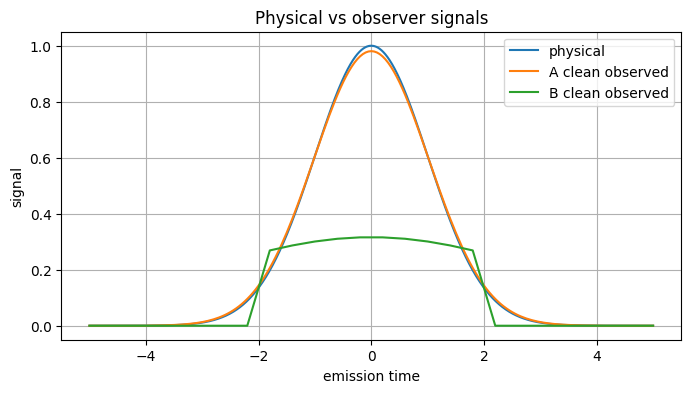

In [15]:
plt.figure(figsize=(8,4))
plt.plot(t_dense,f_dense,label='physical')
plt.plot(dfA_clean['t_emit'],dfA_clean['measured'],label='A clean observed')
plt.plot(dfB_clean['t_emit'],dfB_clean['measured'],label='B clean observed')
plt.xlabel('emission time'); plt.ylabel('signal'); plt.title('Physical vs observer signals'); plt.legend(); plt.grid(True); plt.show()

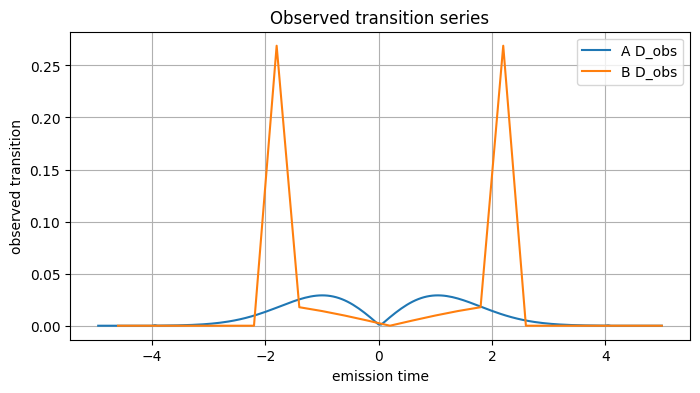

In [16]:
plt.figure(figsize=(8,4))
plt.plot(dfA['t_emit'],dfA['D_obs'],label='A D_obs')
plt.plot(dfB['t_emit'],dfB['D_obs'],label='B D_obs')
plt.xlabel('emission time'); plt.ylabel('observed transition'); plt.title('Observed transition series'); plt.legend(); plt.grid(True); plt.show()

## 15. Verdict automatique
`PASS-STD` signifie que les différences A/B sont compatibles avec la chaîne standard modélisée. `UNRESOLVED` signifie que les contrôles structurels passent mais que le résidu reste insuffisamment expliqué.

In [17]:
residual_pass=bool((np.abs(residual_summary['z_mean'])<3.0).all())
if ideal_pass and constant_pass and residual_pass:
    FINAL_STATUS='PASS-STD'
elif ideal_pass and constant_pass:
    FINAL_STATUS='UNRESOLVED'
else:
    FINAL_STATUS='REJECT-PIPELINE'

artifact={'notebook':'GVH_Diagonal_Cubic_RACC_C3_Two_Observer_Observation_Robustness','scientific_role':'benchmark_observation_interface','core_GVH_modified':False,'D_phys':Dphys,'summary':summary.to_dict(orient='records'),'residual_summary':residual_summary.to_dict(orient='records'),'ideal_limit_pass':ideal_pass,'constant_field_control_pass':constant_pass,'final_status':FINAL_STATUS}
print(json.dumps(artifact,indent=2))
assert FINAL_STATUS=='PASS-STD'

{
  "notebook": "GVH_Diagonal_Cubic_RACC_C3_Two_Observer_Observation_Robustness",
  "scientific_role": "benchmark_observation_interface",
  "core_GVH_modified": false,
  "D_phys": 0.3934693402873666,
  "summary": [
    {
      "observer": "A",
      "D_phys": 0.3934693402873666,
      "D_resolution_only": 0.37428020365066894,
      "D_combined_clean": 0.3742802036506685,
      "D_combined_noise_mean": 0.37418997308186547,
      "D_combined_noise_std": 0.013736148772070597,
      "detection_rate": 1.0,
      "threshold": 0.05
    },
    {
      "observer": "B",
      "D_phys": 0.3934693402873666,
      "D_resolution_only": 0.015422610137494741,
      "D_combined_clean": 0.014790786639566844,
      "D_combined_noise_mean": 0.01595404827460034,
      "D_combined_noise_std": 0.01024508116537645,
      "detection_rate": 0.324,
      "threshold": 0.02
    }
  ],
  "residual_summary": [
    {
      "observer": "A",
      "R_mean": 0.0007991444819519119,
      "R_std": 0.01442721339326934,
   

## 16. Conclusion et stop-rule
Ce notebook valide l'architecture de séparation entre transition physique et transition observée. Aucun résidu n'est attribué à GVH sans contrôles négatifs, limite idéale, correction de propagation et réponse instrumentale explicite.

### Suite proposée
`RACC-C.4` : plusieurs profils physiques (bosse, creux, marche lissée, double structure) avec les mêmes contrôles.